# Figure S5 -- Spatial (position-dependent) TF binding preferences, LogDHT and LogEtOH

Same analysis as `fig5_spatial_model.ipynb` (main-text Figure 5), applied to the
position-dependent (100bp) LogDHT and LogEtOH models instead of LogFC:

- **S5B-style** -- full heatmap + dendrogram of all TFs, ordered/colored by cluster.
- **S5C-style** -- two representative TFs per cluster (closest to centroid, and highest
  absolute weight), split into two panels for readability.
- **TP53 spatial profile** -- the specific thing this notebook was made to check: TP53's
  fitted weight across the 7 spatial bins, for LogFC/LogDHT/LogEtOH side by side.

Expects `../output_files/Ridge_coef_bootstrapped_{lfc,dht,etoh}_bin100bp_..._647mots.npy`
(position-dependent, from `train_model_pipeline.py` run with the `100bp_S0_{lfc,dht,etoh}`
configs) and the matching `..._bin700bp_..._647mots.npy` (position-independent) files.

In [1]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist
from sklearn.cluster import AgglomerativeClustering

sys.path.insert(0, os.path.join('..', 'plotting'))
sys.path.insert(0, '.')
from data_preps import Motifs

OUTPUT_DIR = '../output_files'
INPUT_DIR = '../input_files'
FIGURES_DIR = '../figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

with np.load(f'{INPUT_DIR}/motifs_dict_PWM_pseudo_bg_exp3_JaspHomoLV24_293tf_647mots_LNCaP_aligned.npz') as d:
    motif_pwms = {k: d[k] for k in d.files}
with np.load(f'{INPUT_DIR}/HOCO_uniprot_to_gene.npz') as d:
    conversion = {k: d[k] for k in d.files}
tfs = np.unique(Motifs(motif_pwms, conversion).mot_tfs)
n_tfs = len(tfs)

n_bins = 7
bin_cols = ['0-100', '100-200', '200-300', '300-400', '400-500', '500-600', '600-700']

# Pooling method differs by model/bin-length -- from best_models_hyperparams_MSE_647mots.json
POOLING_100BP = {'lfc': 'maxpooling', 'dht': 'maxpooling', 'etoh': 'maxpooling'}
POOLING_700BP = {'lfc': 'avgpooling', 'dht': 'maxpooling', 'etoh': 'maxpooling'}

OUTPUT_LABELS = {'lfc': 'LogFC', 'dht': 'LogDHT', 'etoh': 'LogEtOH'}

C:\Users\Hoda Taeb\AppData\Local\Programs\Python\Python310\lib\site-packages\matplotlib\projections\__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Load position-dependent (7-bin) and position-independent weights, for all three models

In [2]:
def load_coefs(output_name):
    pd_pattern = os.path.join(OUTPUT_DIR, f'Ridge_coef_bootstrapped_{output_name}_bin100bp_{POOLING_100BP[output_name]}_S0_*647mots.npy')
    pi_pattern = os.path.join(OUTPUT_DIR, f'Ridge_coef_bootstrapped_{output_name}_bin700bp_{POOLING_700BP[output_name]}_S0_*647mots.npy')

    pd_matches = glob.glob(pd_pattern)
    pi_matches = glob.glob(pi_pattern)
    if not pd_matches:
        raise FileNotFoundError(f"No file matching {pd_pattern}. Run train_model_pipeline.py for the 100bp_S0_{output_name} config first.")
    if not pi_matches:
        raise FileNotFoundError(f"No file matching {pi_pattern}. Run train_model_pipeline.py for the 700bp_S0_{output_name} config first.")

    coef_bs_pd = np.load(pd_matches[0])
    coef_bs_pi = np.load(pi_matches[0])

    mean_pd = np.mean(coef_bs_pd, axis=0).reshape(n_bins, n_tfs).T  # (n_tfs, n_bins)
    mean_pi = np.mean(coef_bs_pi, axis=0)                            # (n_tfs,)
    return coef_bs_pd, mean_pd, mean_pi


coefs = {}
for output_name in ['lfc', 'dht', 'etoh']:
    coefs[output_name] = load_coefs(output_name)
    print(f"Loaded {OUTPUT_LABELS[output_name]}: position-dependent {coefs[output_name][0].shape}, position-independent {coefs[output_name][2].shape}")

Loaded LogFC: position-dependent (1000, 2051), position-independent (293,)
Loaded LogDHT: position-dependent (1000, 2051), position-independent (293,)
Loaded LogEtOH: position-dependent (1000, 2051), position-independent (293,)


## TP53 spatial weight profile -- LogFC vs. LogDHT vs. LogEtOH

The specific thing this notebook was made to check: how does TP53's fitted weight vary
across the 7 spatial bins, and does it differ between models?

LogFC TP53 weights per bin: [-0.00782 -0.00797 -0.00764 -0.00735 -0.00705 -0.0047  -0.00157]
LogDHT TP53 weights per bin: [0.16966 0.16941 0.16953 0.15855 0.1455  0.12331 0.05127]
LogEtOH TP53 weights per bin: [0.18213 0.18148 0.18077 0.16916 0.15694 0.13463 0.05853]


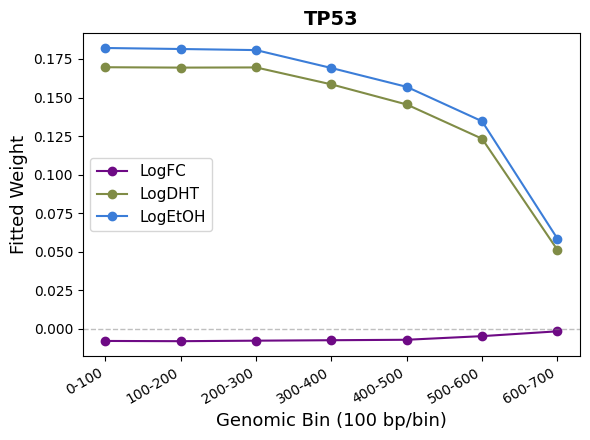

In [3]:
tp53_idx = np.where(tfs == 'TP53')[0][0]

colors = {'lfc': '#6E0A85', 'dht': '#808C46', 'etoh': '#3B7DD8'}

plt.figure(figsize=(6, 4.5))
for output_name in ['lfc', 'dht', 'etoh']:
    _, mean_pd, _ = coefs[output_name]
    tp53_profile = mean_pd[tp53_idx]
    plt.plot(bin_cols, tp53_profile, marker='o', label=OUTPUT_LABELS[output_name], color=colors[output_name])
    print(f"{OUTPUT_LABELS[output_name]} TP53 weights per bin: {np.round(tp53_profile, 5)}")

plt.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
plt.xticks(rotation=30, ha='right')
plt.xlabel('Genomic Bin (100 bp/bin)', fontsize=13)
plt.ylabel('Fitted Weight', fontsize=13)
plt.title('TP53', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/tp53_spatial_profile_lfc_dht_etoh.pdf', bbox_inches='tight')
plt.savefig(f'{FIGURES_DIR}/tp53_spatial_profile_lfc_dht_etoh.svg', bbox_inches='tight')
plt.show()

## 5B-style -- Hierarchical clustering of spatial weight profiles, full heatmap + dendrogram (per model)

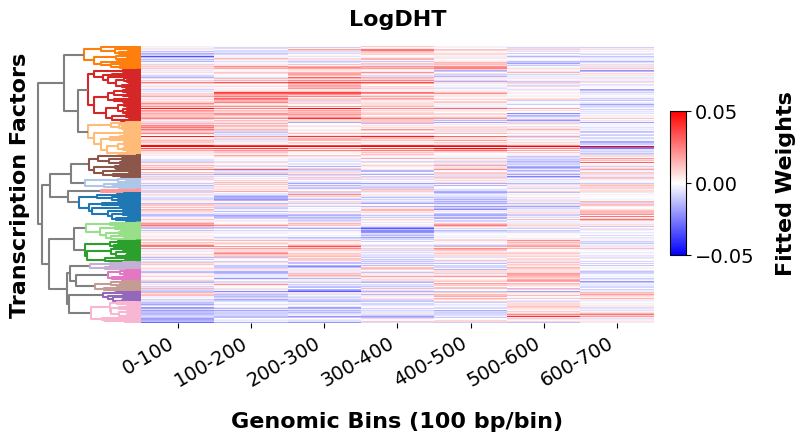

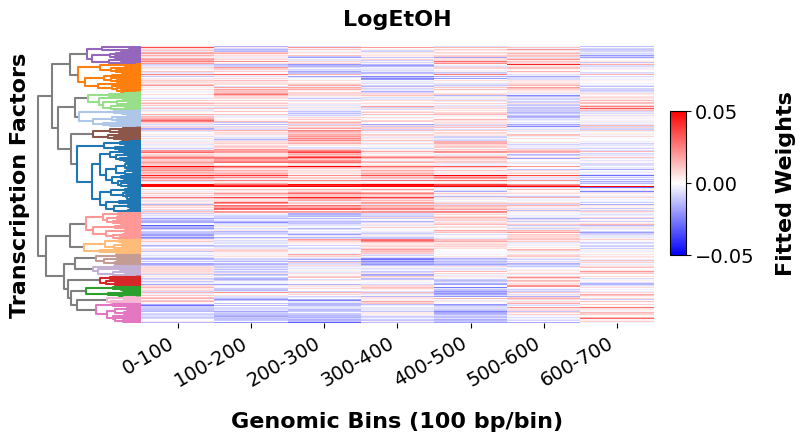

In [4]:
def plot_clustering_heatmap(output_name, n_clusters=14):
    _, mean_pd, _ = coefs[output_name]

    df_clean = pd.DataFrame(mean_pd, columns=bin_cols)
    df_clean['TF_Name'] = tfs
    df_clean = df_clean.drop_duplicates(subset='TF_Name').set_index('TF_Name')

    Z = linkage(df_clean[bin_cols], method='average', metric='correlation')
    dn = dendrogram(Z, no_plot=True)
    leaves_order = dn['leaves']
    df_ordered = df_clean.iloc[leaves_order].copy()

    cluster_model = AgglomerativeClustering(n_clusters=n_clusters, metric='correlation', linkage='average')
    df_clean['cluster'] = cluster_model.fit_predict(df_clean[bin_cols])
    df_ordered['cluster'] = df_clean.loc[df_ordered.index, 'cluster']

    palette = sns.color_palette("tab20", n_clusters)
    hex_palette = [mcolors.to_hex(c) for c in palette]
    row_colors = [palette[int(c)] for c in df_ordered['cluster']]

    def get_link_color(k):
        n = len(df_clean)
        if k < n:
            return hex_palette[int(df_clean.iloc[k]['cluster'])]
        left, right = Z[k - n, 0], Z[k - n, 1]
        c_left = get_link_color(int(left))
        c_right = get_link_color(int(right))
        return c_left if c_left == c_right else '#808080'

    fig = plt.figure(figsize=(8, 3.6))
    gs = gridspec.GridSpec(1, 3, width_ratios=[2, 0.1, 10], wspace=0.0)

    ax_dendro = plt.subplot(gs[0])
    dendrogram(Z, ax=ax_dendro, orientation='left',
               link_color_func=get_link_color, color_threshold=0,
               no_labels=True)
    ax_dendro.invert_yaxis()
    ax_dendro.axis('off')

    ax_color = plt.subplot(gs[1])
    color_array = np.array([row_colors]).reshape(len(row_colors), 1, 3)
    ax_color.imshow(color_array, aspect='auto', origin='upper')
    ax_color.axis('off')

    vmin, vmax = -0.05, 0.05
    ax_heatmap = plt.subplot(gs[2])
    sns.heatmap(df_ordered[bin_cols],
                ax=ax_heatmap,
                cmap='bwr',
                center=0, vmin=vmin, vmax=vmax,
                cbar=False,
                xticklabels=True,
                yticklabels=False)

    ax_heatmap.set_ylabel('Transcription Factors', fontsize=16, fontweight='bold', labelpad=80)
    ax_heatmap.set_xlabel('Genomic Bins (100 bp/bin)', fontsize=16, fontweight='bold', labelpad=15)
    ax_heatmap.set_xticklabels(ax_heatmap.get_xticklabels(),
                               rotation=30,
                               ha='right',
                               fontsize=14,
                               fontweight='normal')
    ax_heatmap.set_title(OUTPUT_LABELS[output_name], fontsize=16, fontweight='bold', pad=15)

    cbar_ax = fig.add_axes([0.92, 0.3, 0.02, 0.4])
    sm = plt.cm.ScalarMappable(cmap='bwr', norm=plt.Normalize(vmin=vmin, vmax=vmax))
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('Fitted Weights', fontsize=16, fontweight='bold', labelpad=15)
    cbar.ax.tick_params(labelsize=14)

    fig.savefig(f'{FIGURES_DIR}/fig5b_spatial_clustering_heatmap_{output_name}.pdf', bbox_inches='tight')
    fig.savefig(f'{FIGURES_DIR}/fig5b_spatial_clustering_heatmap_{output_name}.svg', bbox_inches='tight')
    plt.show()

    return df_clean


clean_dfs = {}
for output_name in ['dht', 'etoh']:
    clean_dfs[output_name] = plot_clustering_heatmap(output_name)

## 5C-style -- Representative TF weight profiles per cluster (two per cluster: closest to centroid, and highest absolute weight), split into two panels for readability (per model)

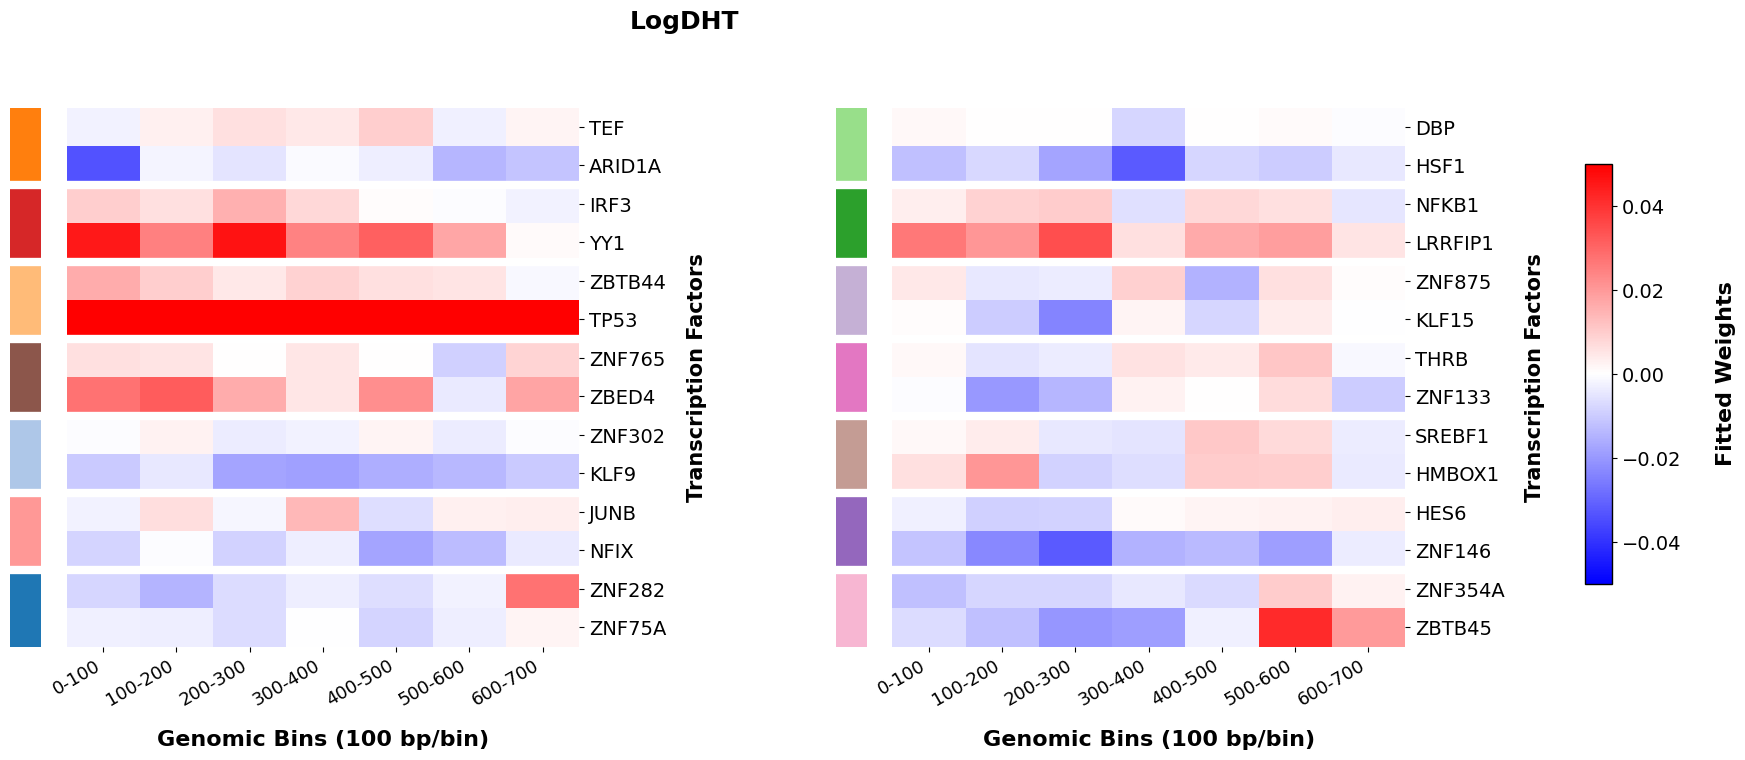

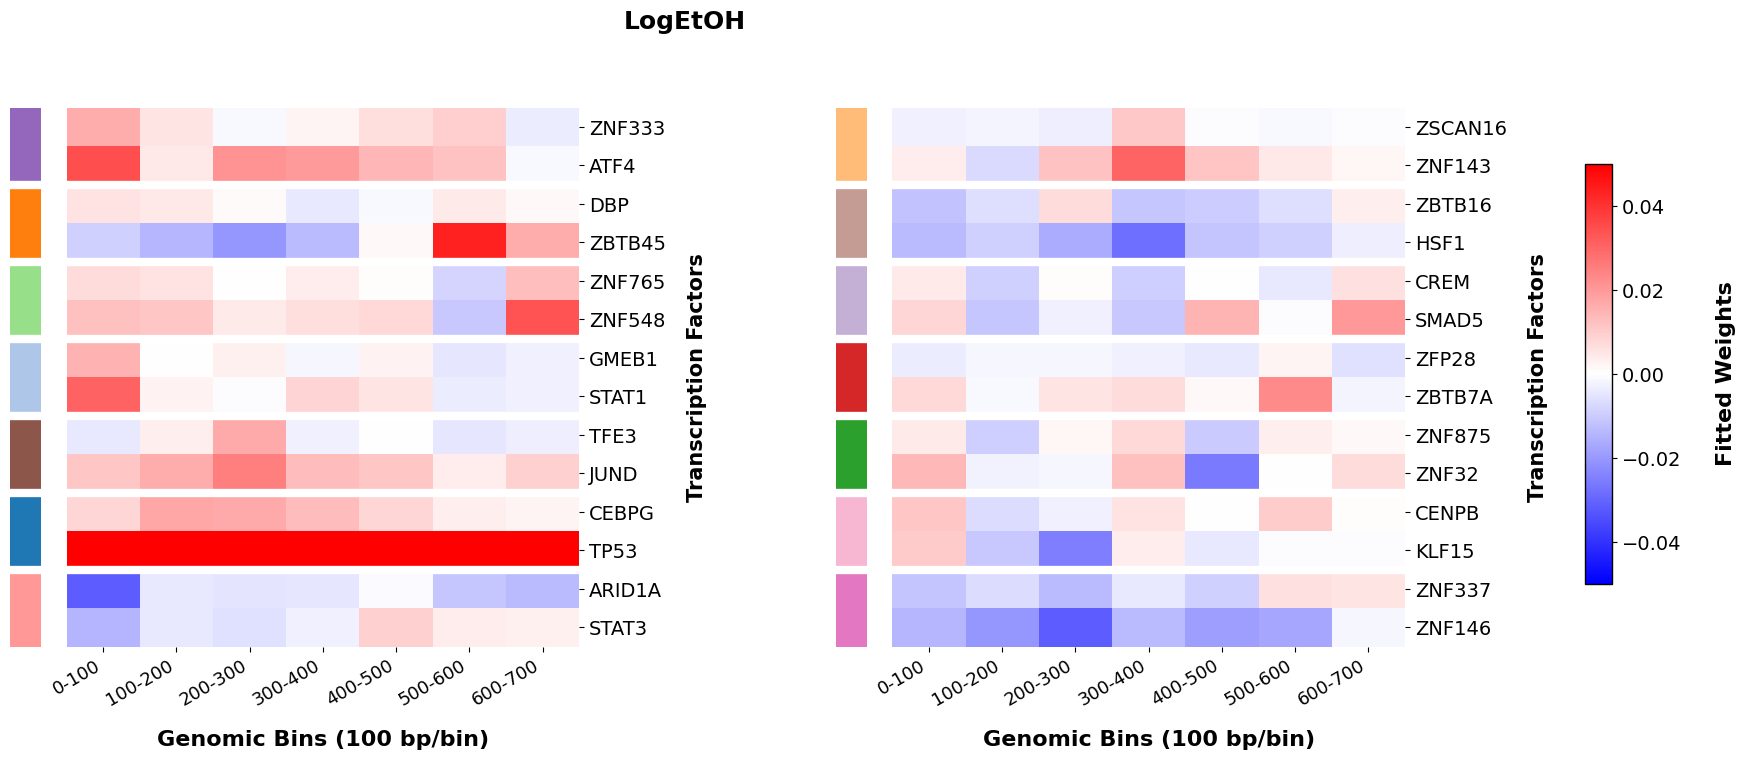

In [5]:
def plot_representative_profiles(output_name, n_clusters=14):
    _, mean_pd, _ = coefs[output_name]

    df_clean = pd.DataFrame(mean_pd, columns=bin_cols)
    df_clean['TF_Name'] = tfs
    df_clean = df_clean.drop_duplicates(subset='TF_Name').set_index('TF_Name')

    Z = linkage(df_clean[bin_cols], method='average', metric='correlation')
    dn = dendrogram(Z, no_plot=True)
    tree_order_tfs = df_clean.index[dn['leaves']].tolist()

    cluster_model = AgglomerativeClustering(n_clusters=n_clusters, metric='correlation', linkage='average')
    df_clean['cluster'] = cluster_model.fit_predict(df_clean[bin_cols])
    df_clean['strength'] = df_clean[bin_cols].abs().max(axis=1)

    cluster_order = []
    for tf in tree_order_tfs:
        c_id = df_clean.loc[tf, 'cluster']
        if c_id not in cluster_order:
            cluster_order.append(c_id)

    selected_indices = []
    for i in cluster_order:
        cluster_subset = df_clean[df_clean['cluster'] == i]

        centroid_vector = cluster_subset[bin_cols].mean(axis=0).values.reshape(1, -1)
        distances_to_centroid = cdist(centroid_vector, cluster_subset[bin_cols].values, metric='euclidean').flatten()
        closest_to_centroid_name = cluster_subset.index[np.argsort(distances_to_centroid)[0]]

        if len(cluster_subset) >= 2:
            max_abs_tf_name = cluster_subset.sort_values('strength', ascending=False).index[0]

            if closest_to_centroid_name == max_abs_tf_name:
                closest_to_centroid_name = cluster_subset.index[np.argsort(distances_to_centroid)[1]]

            selected_indices.extend([closest_to_centroid_name, max_abs_tf_name])
        else:
            selected_indices.extend(cluster_subset.index.tolist())

    final_df = df_clean.loc[selected_indices].copy()
    final_df['cluster'] = pd.Categorical(final_df['cluster'], categories=cluster_order, ordered=True)
    final_df = final_df.sort_values('cluster')

    df_part1 = final_df[final_df['cluster'].isin(cluster_order[:7])]
    df_part2 = final_df[final_df['cluster'].isin(cluster_order[7:])]

    palette = sns.color_palette("tab20", n_clusters)
    fig = plt.figure(figsize=(18, 7))
    gs = gridspec.GridSpec(1, 5, width_ratios=[0.6, 10, 4.0, 0.6, 10], wspace=0.1)

    vmin, vmax = -0.05, 0.05

    def plot_panel(target_df, ax_color, ax_heat, title):
        cluster_ids = target_df['cluster'].astype(int).values
        color_data = np.array([[palette[c] for c in cluster_ids]]).reshape(len(cluster_ids), 1, 3)
        ax_color.imshow(color_data, aspect='auto')
        ax_color.set_axis_off()

        sns.heatmap(target_df[bin_cols],
                    ax=ax_heat,
                    cmap='bwr',
                    center=0, vmin=vmin, vmax=vmax,
                    cbar=False,
                    xticklabels=True,
                    yticklabels=True)

        ax_heat.yaxis.tick_right()
        ax_heat.yaxis.set_label_position("right")
        ax_heat.set_ylabel('')
        ax_heat.set_xlabel('')

        ax_heat.tick_params(axis='x', rotation=30, labelsize=13)
        ax_heat.set_ylabel('Transcription Factors', fontsize=15, fontweight='bold', labelpad=15)
        ax_heat.yaxis.set_label_position("right")

        for label in ax_heat.get_xticklabels():
            label.set_ha('right')

        ax_heat.tick_params(axis='y', rotation=0, labelsize=14)

        num_rows = len(target_df)
        for i in range(2, num_rows, 2):
            ax_heat.axhline(y=i, color='white', linewidth=6, zorder=10)
            ax_color.axhline(y=i - 0.5, color='white', linewidth=6, zorder=10)

        ax_heat.set_xlabel('Genomic Bins (100 bp/bin)', fontsize=16, fontweight='bold', labelpad=15)

    ax_c1, ax_h1 = plt.subplot(gs[0]), plt.subplot(gs[1])
    plot_panel(df_part1, ax_c1, ax_h1, "Pattern Groups 1-7")

    ax_c2, ax_h2 = plt.subplot(gs[3]), plt.subplot(gs[4])
    plot_panel(df_part2, ax_c2, ax_h2, "Pattern Groups 8-14")

    fig.suptitle(OUTPUT_LABELS[output_name], fontsize=18, fontweight='bold', y=1.02)

    cbar_ax = fig.add_axes([1, 0.2, 0.015, 0.6])
    sm = plt.cm.ScalarMappable(cmap='bwr', norm=plt.Normalize(vmin=vmin, vmax=vmax))
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('Fitted Weights', fontsize=16, fontweight='bold', labelpad=25)
    cbar.ax.tick_params(labelsize=14)
    cbar.outline.set_linewidth(1)

    fig.savefig(f'{FIGURES_DIR}/fig5c_representative_tf_profiles_{output_name}.pdf', bbox_inches='tight')
    fig.savefig(f'{FIGURES_DIR}/fig5c_representative_tf_profiles_{output_name}.svg', bbox_inches='tight')
    plt.show()


for output_name in ['dht', 'etoh']:
    plot_representative_profiles(output_name)

## Combined supplementary figure -- 4 panels (A-D)

Row 1: clustering heatmap+dendrogram for LogDHT (A) and LogEtOH (B), side by side.
Row 2: representative-TF profiles for LogDHT (C).
Row 3: representative-TF profiles for LogEtOH (D).

Draws each panel directly into one shared figure (rather than re-running the
per-model functions above, which each make their own standalone figure), so
panel labels/colorbar/caption can be added once. Uses the same `vmin`/`vmax`
(+/-0.05) as the per-model plots above.

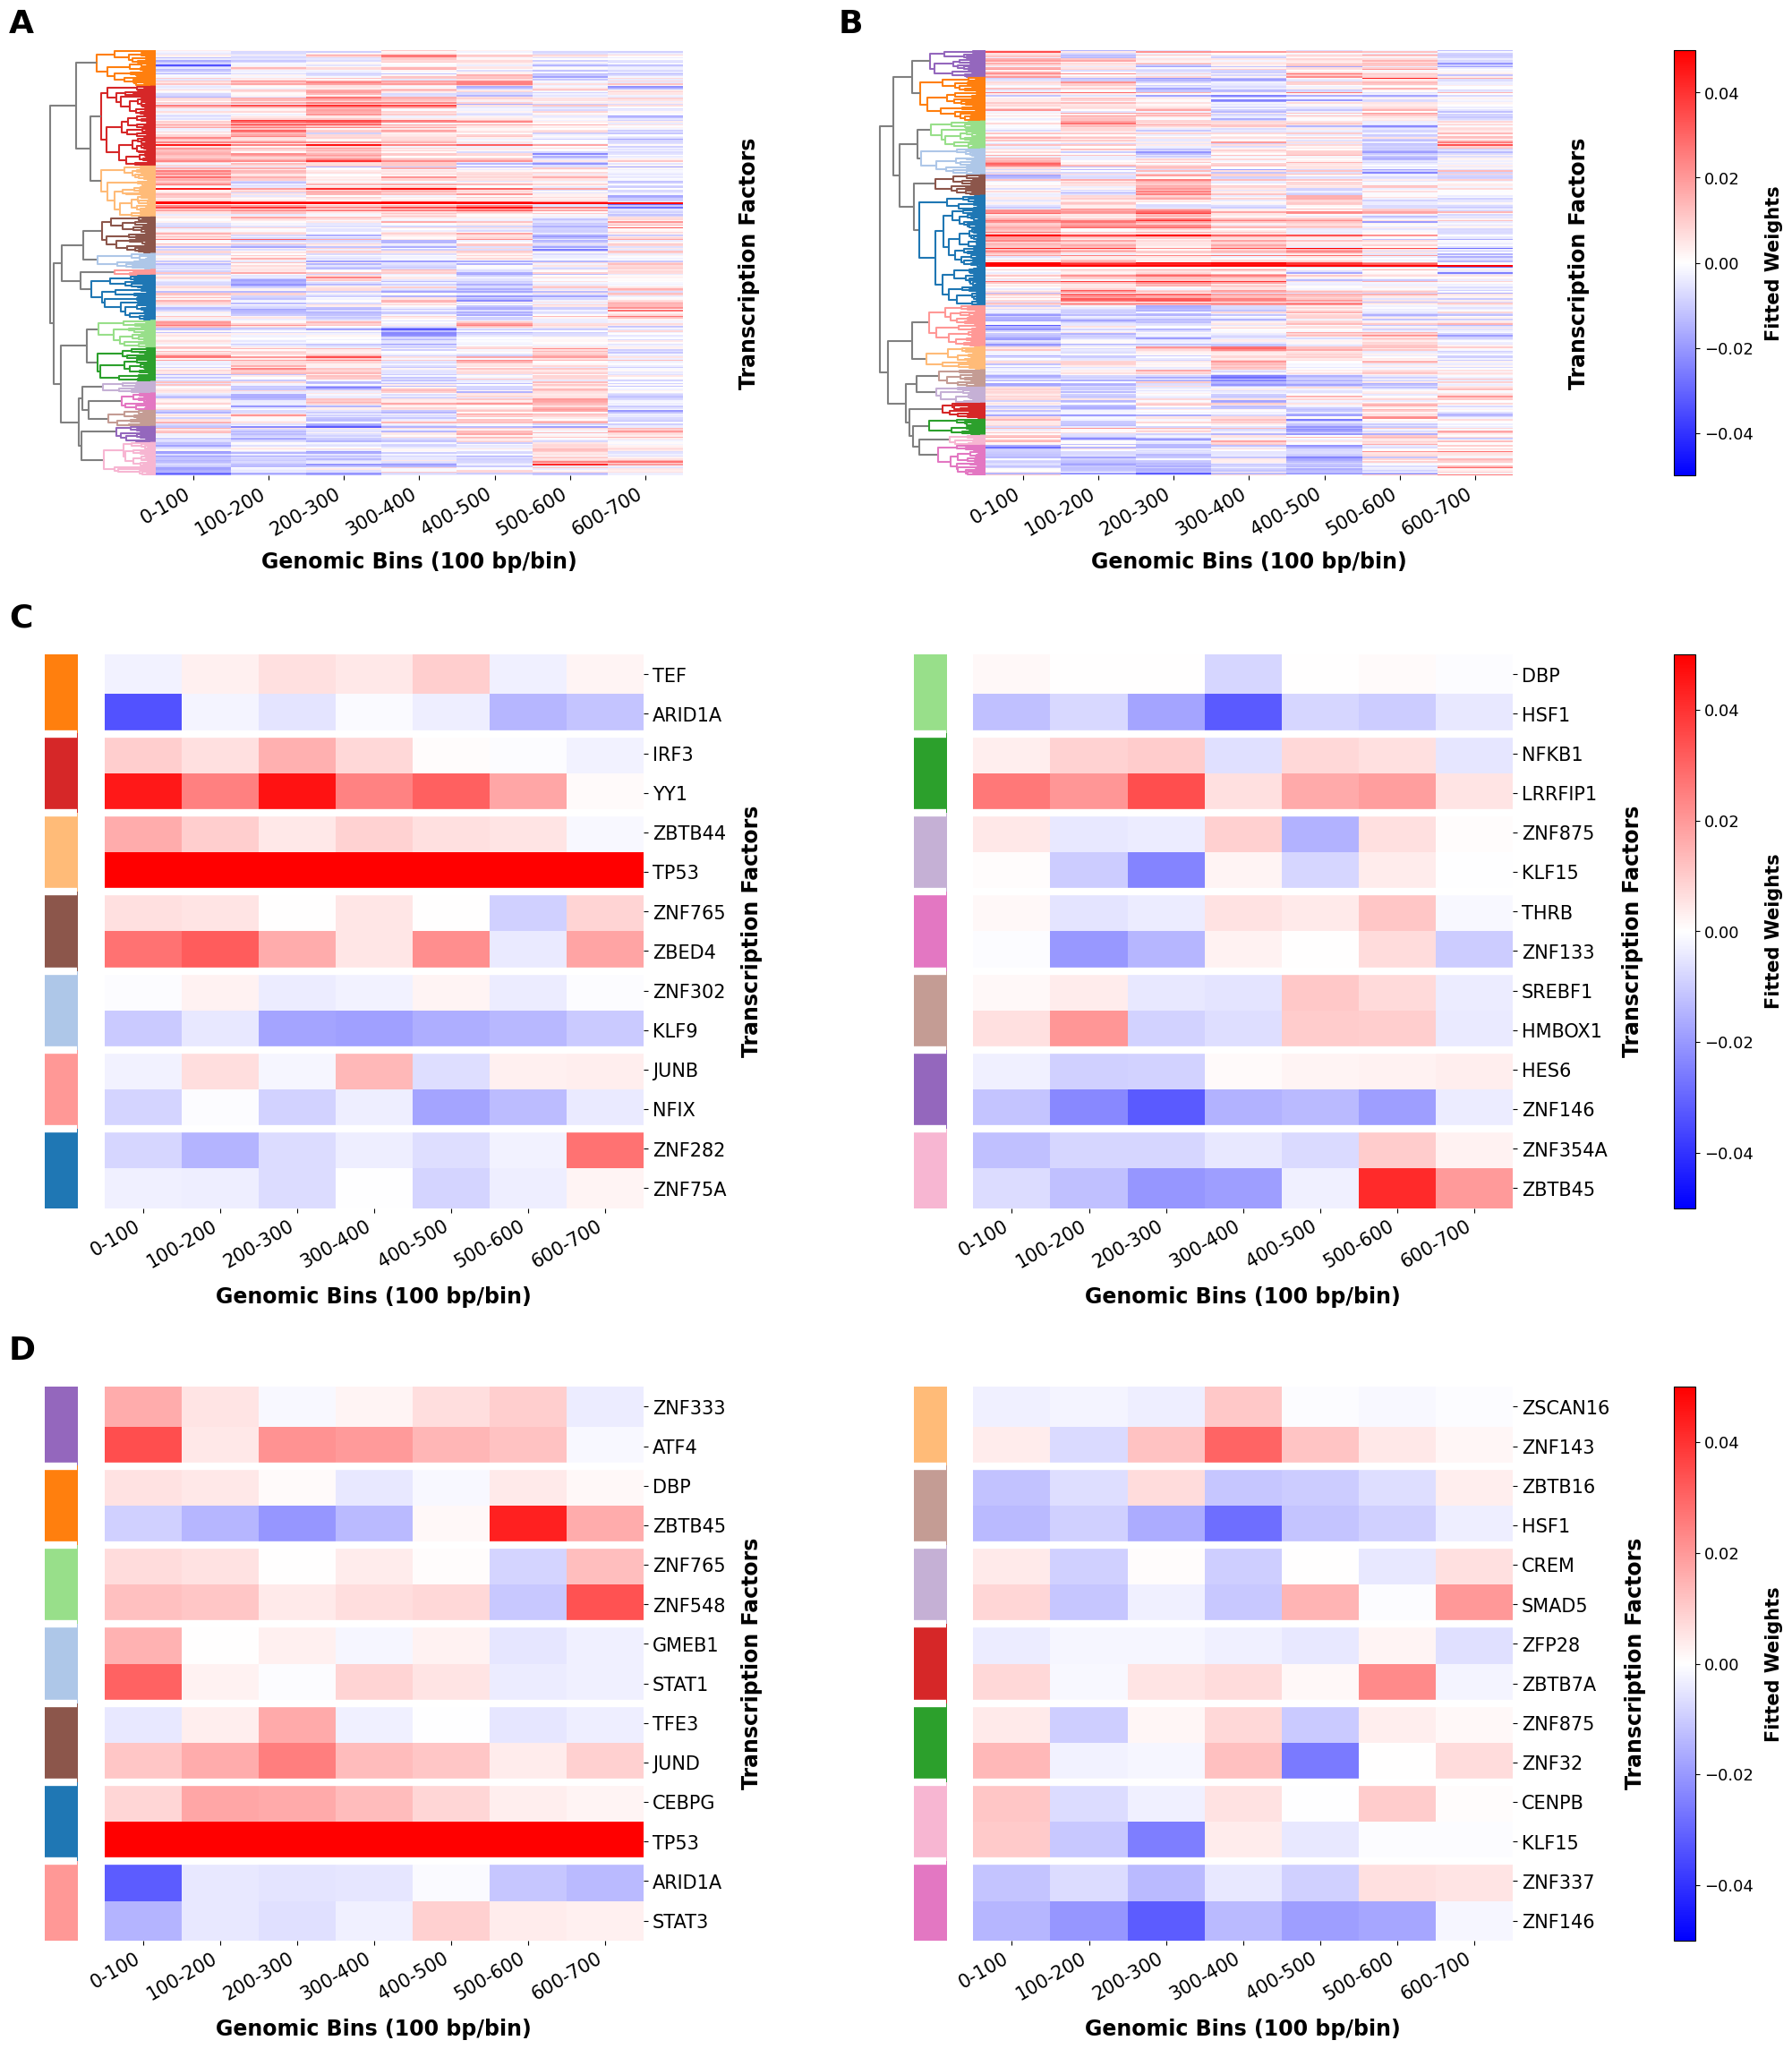

In [6]:
def draw_clustering_panel(fig, subplot_spec, output_name, panel_label, n_clusters=14, vmin=-0.05, vmax=0.05):
    _, mean_pd, _ = coefs[output_name]

    df_clean = pd.DataFrame(mean_pd, columns=bin_cols)
    df_clean['TF_Name'] = tfs
    df_clean = df_clean.drop_duplicates(subset='TF_Name').set_index('TF_Name')

    Z = linkage(df_clean[bin_cols], method='average', metric='correlation')
    dn = dendrogram(Z, no_plot=True)
    leaves_order = dn['leaves']
    df_ordered = df_clean.iloc[leaves_order].copy()

    cluster_model = AgglomerativeClustering(n_clusters=n_clusters, metric='correlation', linkage='average')
    df_clean['cluster'] = cluster_model.fit_predict(df_clean[bin_cols])
    df_ordered['cluster'] = df_clean.loc[df_ordered.index, 'cluster']

    palette = sns.color_palette("tab20", n_clusters)
    hex_palette = [mcolors.to_hex(c) for c in palette]
    row_colors = [palette[int(c)] for c in df_ordered['cluster']]

    def get_link_color(k):
        n = len(df_clean)
        if k < n:
            return hex_palette[int(df_clean.iloc[k]['cluster'])]
        left, right = Z[k - n, 0], Z[k - n, 1]
        c_left = get_link_color(int(left))
        c_right = get_link_color(int(right))
        return c_left if c_left == c_right else '#808080'

    inner = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=subplot_spec, width_ratios=[2, 0.1, 10], wspace=0.0)

    ax_dendro = fig.add_subplot(inner[0])
    dendrogram(Z, ax=ax_dendro, orientation='left',
               link_color_func=get_link_color, color_threshold=0,
               no_labels=True)
    ax_dendro.invert_yaxis()
    ax_dendro.axis('off')

    ax_color = fig.add_subplot(inner[1])
    color_array = np.array([row_colors]).reshape(len(row_colors), 1, 3)
    ax_color.imshow(color_array, aspect='auto', origin='upper')
    ax_color.axis('off')

    ax_heatmap = fig.add_subplot(inner[2])
    sns.heatmap(df_ordered[bin_cols],
                ax=ax_heatmap,
                cmap='bwr',
                center=0, vmin=vmin, vmax=vmax,
                cbar=False,
                xticklabels=True,
                yticklabels=False)

    ax_heatmap.set_ylabel('Transcription Factors', fontsize=17, fontweight='bold', labelpad=-486)
    ax_heatmap.set_xlabel('Genomic Bins (100 bp/bin)', fontsize=17, fontweight='bold', labelpad=10)
    ax_heatmap.set_xticklabels(ax_heatmap.get_xticklabels(), rotation=30, ha='right', fontsize=15)

    bbox = subplot_spec.get_position(fig)
    fig.text(bbox.x0 - 0.02, bbox.y1 + 0.005, panel_label, fontsize=26, fontweight='bold', va='bottom', ha='left')


def draw_representative_panel(fig, subplot_spec, output_name, panel_label, n_clusters=14, vmin=-0.05, vmax=0.05):
    _, mean_pd, _ = coefs[output_name]

    df_clean = pd.DataFrame(mean_pd, columns=bin_cols)
    df_clean['TF_Name'] = tfs
    df_clean = df_clean.drop_duplicates(subset='TF_Name').set_index('TF_Name')

    Z = linkage(df_clean[bin_cols], method='average', metric='correlation')
    dn = dendrogram(Z, no_plot=True)
    tree_order_tfs = df_clean.index[dn['leaves']].tolist()

    cluster_model = AgglomerativeClustering(n_clusters=n_clusters, metric='correlation', linkage='average')
    df_clean['cluster'] = cluster_model.fit_predict(df_clean[bin_cols])
    df_clean['strength'] = df_clean[bin_cols].abs().max(axis=1)

    cluster_order = []
    for tf in tree_order_tfs:
        c_id = df_clean.loc[tf, 'cluster']
        if c_id not in cluster_order:
            cluster_order.append(c_id)

    selected_indices = []
    for i in cluster_order:
        cluster_subset = df_clean[df_clean['cluster'] == i]
        centroid_vector = cluster_subset[bin_cols].mean(axis=0).values.reshape(1, -1)
        distances_to_centroid = cdist(centroid_vector, cluster_subset[bin_cols].values, metric='euclidean').flatten()
        closest_to_centroid_name = cluster_subset.index[np.argsort(distances_to_centroid)[0]]

        if len(cluster_subset) >= 2:
            max_abs_tf_name = cluster_subset.sort_values('strength', ascending=False).index[0]
            if closest_to_centroid_name == max_abs_tf_name:
                closest_to_centroid_name = cluster_subset.index[np.argsort(distances_to_centroid)[1]]
            selected_indices.extend([closest_to_centroid_name, max_abs_tf_name])
        else:
            selected_indices.extend(cluster_subset.index.tolist())

    final_df = df_clean.loc[selected_indices].copy()
    final_df['cluster'] = pd.Categorical(final_df['cluster'], categories=cluster_order, ordered=True)
    final_df = final_df.sort_values('cluster')

    df_part1 = final_df[final_df['cluster'].isin(cluster_order[:7])]
    df_part2 = final_df[final_df['cluster'].isin(cluster_order[7:])]

    palette = sns.color_palette("tab20", n_clusters)
    inner = gridspec.GridSpecFromSubplotSpec(1, 5, subplot_spec=subplot_spec, width_ratios=[0.6, 10, 4.0, 0.6, 10], wspace=0.1)

    def plot_panel(target_df, ax_color, ax_heat):
        cluster_ids = target_df['cluster'].astype(int).values
        color_data = np.array([[palette[c] for c in cluster_ids]]).reshape(len(cluster_ids), 1, 3)
        ax_color.imshow(color_data, aspect='auto')
        ax_color.set_axis_off()

        sns.heatmap(target_df[bin_cols],
                    ax=ax_heat,
                    cmap='bwr',
                    center=0, vmin=vmin, vmax=vmax,
                    cbar=False,
                    xticklabels=True,
                    yticklabels=True)

        ax_heat.yaxis.tick_right()
        ax_heat.yaxis.set_label_position("right")
        ax_heat.set_ylabel('')
        ax_heat.set_xlabel('')

        ax_heat.tick_params(axis='x', rotation=30, labelsize=15)
        ax_heat.set_ylabel('Transcription Factors', fontsize=17, fontweight='bold', labelpad=12)
        ax_heat.yaxis.set_label_position("right")

        for label in ax_heat.get_xticklabels():
            label.set_ha('right')

        ax_heat.tick_params(axis='y', rotation=0, labelsize=15)

        num_rows = len(target_df)
        for i in range(2, num_rows, 2):
            ax_heat.axhline(y=i, color='white', linewidth=6, zorder=10)
            ax_color.axhline(y=i - 0.5, color='white', linewidth=6, zorder=10)

        ax_heat.set_xlabel('Genomic Bins (100 bp/bin)', fontsize=17, fontweight='bold', labelpad=12)

    ax_c1 = fig.add_subplot(inner[0])
    ax_h1 = fig.add_subplot(inner[1])
    plot_panel(df_part1, ax_c1, ax_h1)

    ax_c2 = fig.add_subplot(inner[3])
    ax_h2 = fig.add_subplot(inner[4])
    plot_panel(df_part2, ax_c2, ax_h2)

    bbox = subplot_spec.get_position(fig)
    fig.text(bbox.x0 - 0.02, bbox.y1 + 0.01, panel_label, fontsize=26, fontweight='bold', va='bottom', ha='left')


VMIN, VMAX = -0.05, 0.05

fig = plt.figure(figsize=(20, 24))
outer = gridspec.GridSpec(3, 1, height_ratios=[1, 1.3, 1.3], hspace=0.35,
                           left=0.06, right=0.88, top=0.94, bottom=0.06, figure=fig)

row1 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[0], wspace=0.3)
draw_clustering_panel(fig, row1[0], 'dht', 'A', vmin=VMIN, vmax=VMAX)
draw_clustering_panel(fig, row1[1], 'etoh', 'B', vmin=VMIN, vmax=VMAX)

draw_representative_panel(fig, outer[1], 'dht', 'C', vmin=VMIN, vmax=VMAX)
draw_representative_panel(fig, outer[2], 'etoh', 'D', vmin=VMIN, vmax=VMAX)

# One colorbar per row, shifted further right of the panels
CBAR_X = 0.97


def add_row_colorbar(fig, subplot_spec, vmin, vmax, x=CBAR_X, width=0.012):
    bbox = subplot_spec.get_position(fig)
    cbar_ax = fig.add_axes([x, bbox.y0, width, bbox.height])
    sm = plt.cm.ScalarMappable(cmap='bwr', norm=plt.Normalize(vmin=vmin, vmax=vmax))
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('Fitted Weights', fontsize=15, fontweight='bold', labelpad=10)
    cbar.ax.tick_params(labelsize=13)


add_row_colorbar(fig, outer[0], VMIN, VMAX)
add_row_colorbar(fig, outer[1], VMIN, VMAX)
add_row_colorbar(fig, outer[2], VMIN, VMAX)



fig.savefig(f'{FIGURES_DIR}/figS_spatial_clustering_dht_etoh_combined.pdf', bbox_inches='tight')
fig.savefig(f'{FIGURES_DIR}/figS_spatial_clustering_dht_etoh_combined.svg', bbox_inches='tight')
plt.show()